## <center> **Multiple regression**
    
We are going to compare simple and multiple regression ...

In [1]:
import numpy as np
import pandas as pd

dict_ = {"mouseWeight": [0.9, 1.8, 2.4, 3.5, 3.9, 4.4, 5.1, 5.6, 6.3],
         "mouseSize": [1.4, 2.6, 1.0, 3.7, 5.5, 3.2, 3.0, 4.9, 6.3],
         "mouseTail": [0.7, 1.3, 0.7, 2.0, 3.6, 3.0, 2.9, 3.9, 4.0]
        }

df = pd.DataFrame(dict_)

### Simple regression

Step 1: always plot your data!

Plotting your data as a first step is super important, because it allows us to evaluate whether doing a linear regression to begin with is a good a idea. Can we see a relationship in the data between size and weight ?

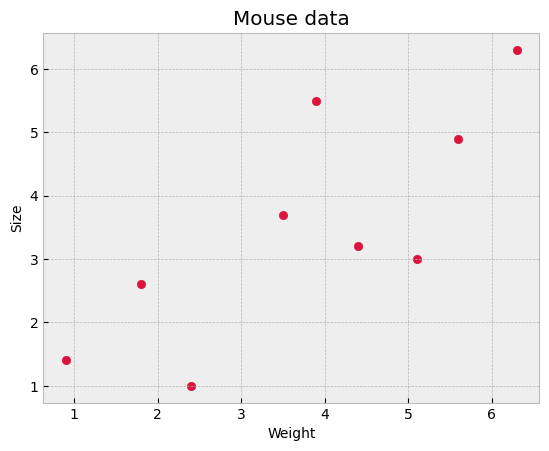

In [2]:
# Plot the data
import matplotlib.pyplot as plt

plt.style.use('bmh')
plt.scatter(df.mouseWeight, df.mouseSize, color="crimson")
plt.xlabel("Weight"); plt.ylabel("Size"); plt.title("Mouse data")
plt.show()

Step 2: fit a line to the data, calculate R-squared and the p-value

In [3]:
import statsmodels.api as sm

X = df['mouseWeight'].values
y =  df['mouseSize'].values

# Add a constant to the independent variables
X = sm.add_constant(X) # DESIGN MATRIX !

# Create and fit the linear regression model
simple_model = sm.OLS(y, X)
line = simple_model.fit()

# Print the summary
print(line.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     11.10
Date:                Wed, 12 Jul 2023   Prob (F-statistic):             0.0126
Time:                        18:30:02   Log-Likelihood:                -13.208
No. Observations:                   9   AIC:                             30.42
Df Residuals:                       7   BIC:                             30.81
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5813      0.965      0.603      0.5

C:\Users\tnimo\AppData\Local\anaconda3\lib\site-packages\scipy\stats\_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


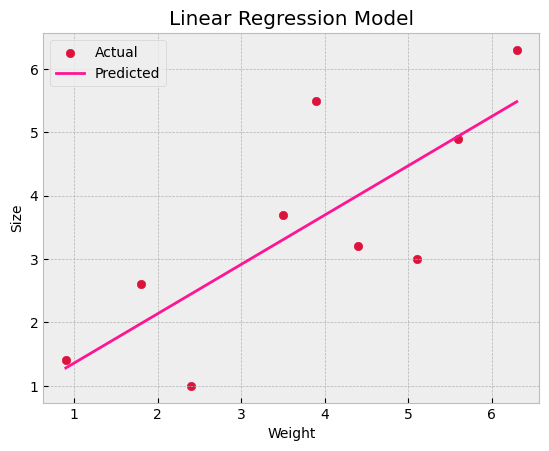

In [4]:
# Predict the size using the trained model
y_pred = line.predict(X)

# Plot the fit
plt.scatter(df.mouseWeight, df.mouseSize, color='crimson', label='Actual')
plt.plot(df.mouseWeight, y_pred, color='deeppink', label='Predicted')
plt.title('Linear Regression Model'); plt.legend()
plt.xlabel('Weight'); plt.ylabel('Size')
plt.show()

### Multiple regression

For multiple regression, we will use weight and tail length to predict size ...

Step 1: always plot your data!

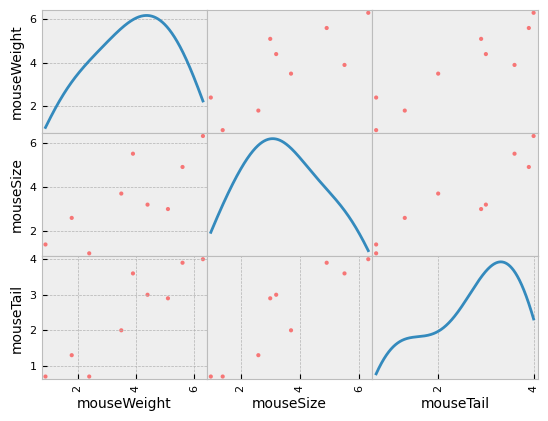

In [5]:
pd.plotting.scatter_matrix(df, diagonal="kde", color="red");

We can see that both weight and tail are correlated with size. This is good ! It means that both variables are reasonable predictors for our target.

We can also see that weight and tail are correlated - this means that they provide similar information and that we might not need both in our model.

Step 2: fit a plane to the data

In [10]:
import statsmodels.api as sm

X = df[['mouseWeight', 'mouseTail']].values
y =  df['mouseSize'].values

# Add a constant to the independent variables
X = sm.add_constant(X) # DESIGN MATRIX !

# Create and fit the linear regression model
model = sm.OLS(y, X)
plane = model.fit()

# Print the summary
print(plane.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.800
Method:                 Least Squares   F-statistic:                     16.95
Date:                Wed, 12 Jul 2023   Prob (F-statistic):            0.00340
Time:                        18:32:18   Log-Likelihood:                -8.9568
No. Observations:                   9   AIC:                             23.91
Df Residuals:                       6   BIC:                             24.51
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7070      0.651      1.086      0.3

C:\Users\tnimo\AppData\Local\anaconda3\lib\site-packages\scipy\stats\_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


The R-squared, **adjusted R-squared** and the p-value look good !!!

NOTE: since we are doing multiple regression we are now more interested in the adjusted R-squared value.

With multiple regression the **coefficients** section is more interesting:

- The line for **x1 (weight)** ...

    ... compares this fancy model $\text{size}=\text{b}+\text{a}_1\text{weight}+\text{a}_2\text{tail}$ to this simple model $\text{size}=\text{b}+\text{a}_2\text{tail}$.

    The p-value (0,435 > 0,05) means that using weight and tail isn´t significantly better than using tail alone to predict size.
    
- The line for **x2 (tail)** ...

    ... compares this fancy model $\text{size}=\text{b}+\text{a}_1\text{weight}+\text{a}_2\text{tail}$ to this simple model $\text{size}=\text{b}+\text{a}_1\text{weight}$.

    The p-value (0,0219 > 0,05) means that using weight and tail is significantly better than using weight alone to predict size.
    
In conclusion using weight and tail to predict size is good ... but if we wanted to save time, we could spare ourselves the agony of weighting mice and just use their tail lengths to predict size.

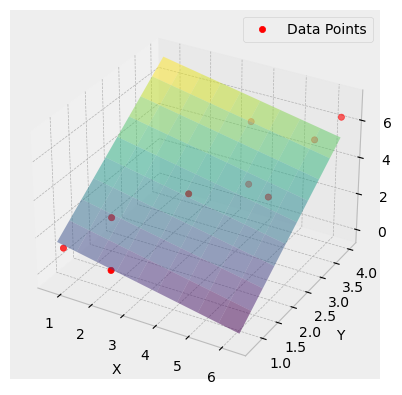

In [14]:
from mpl_toolkits.mplot3d import Axes3D

x = df.mouseWeight
y = df.mouseTail
z = df.mouseSize

# Retrieve the plane parameters
intercept, slope_x, slope_y = plane.params

# Create a meshgrid of x and y values for plotting the plane:
xx, yy = np.meshgrid(np.linspace(X.min(), x.max(), 10), np.linspace(y.min(), y.max(), 10))
zz = intercept + slope_x * xx + slope_y * yy

# Create a 3D plot and scatter the original data points:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c='red', label='Data Points')

# Plot the fitted plane:
ax.plot_surface(xx, yy, zz, alpha=0.5, cmap='viridis')

# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

plt.show()

---